In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"✅ All seeds locked to {SEED} — 100% reproducible results guaranteed")

✅ All seeds locked to 42 — 100% reproducible results guaranteed


✅ All libraries loaded successfully
   TensorFlow version : 2.19.0
   NumPy version      : 2.0.2


✅ Plot style configured — dark GitHub-inspired theme


Loading subjects:   0%|          | 0/32 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════
  DEAP DATASET — LOADED SUCCESSFULLY
═══════════════════════════════════════════════════════
  EEG data shape    : (1280, 32, 7680)
  Labels shape      : (1280, 4)
  Sampling rate     : 128 Hz
  Duration/trial    : 60.0 s
  Total trials      : 1280
  EEG channels      : 32
───────────────────────────────────────────────────────
  Labels [0] Valence   – range: [1.0, 9.0]
  Labels [1] Arousal   – range: [1.0, 9.0]
  Labels [2] Dominance – range: [1.0, 9.0]
  Labels [3] Liking    – range: [1.0, 9.0]
═══════════════════════════════════════════════════════


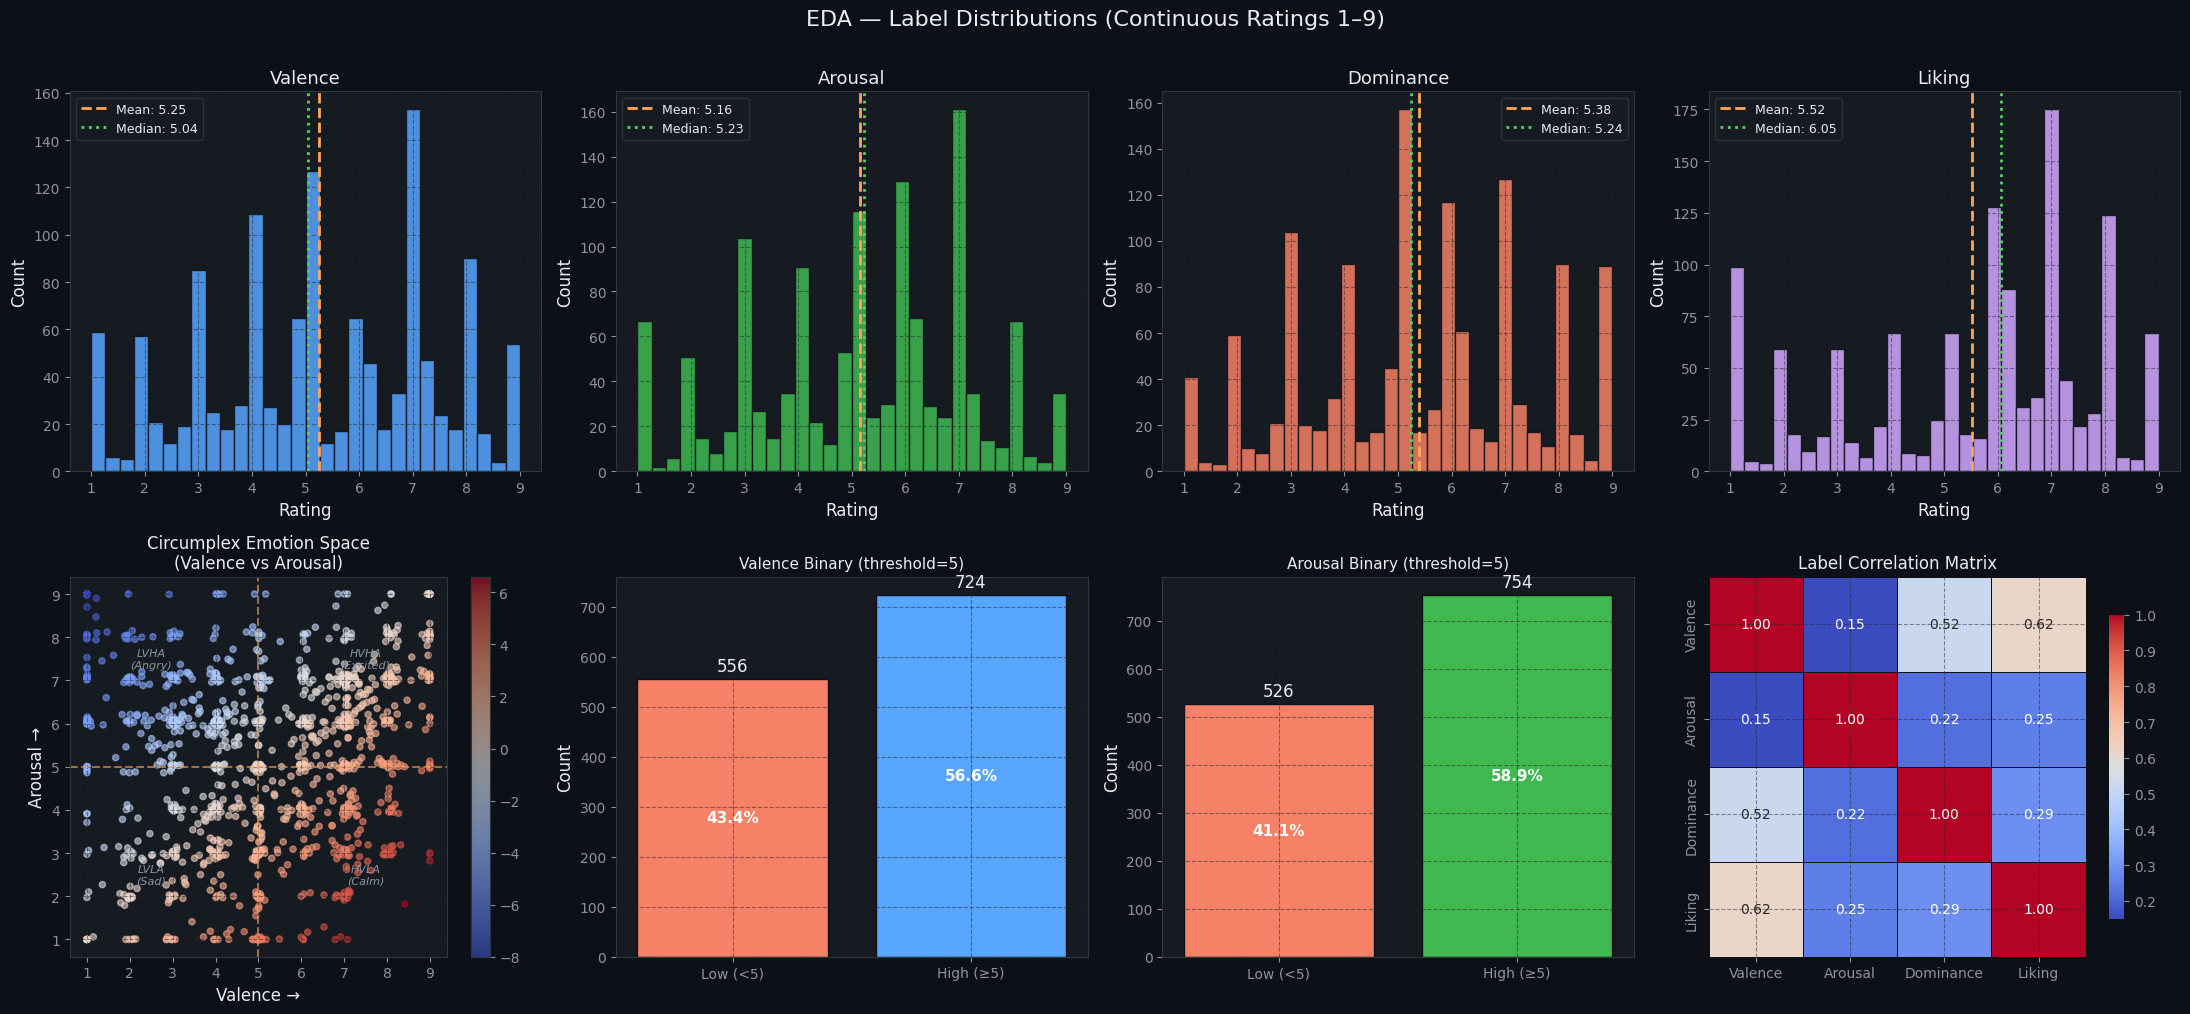


📊 Binary class balance:
   Valence  — Low: 556  High: 724
   Arousal  — Low: 526  High: 754


In [7]:
label_names = ['Valence', 'Arousal', 'Dominance', 'Liking']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('EDA — Label Distributions (Continuous Ratings 1–9)', fontsize=16, y=1.01, color='#e6edf3')

for i, (ax, name) in enumerate(zip(axes[0], label_names)):
    vals = labels[:, i]
    ax.hist(vals, bins=30, color=PALETTE[i], edgecolor='#0d1117', alpha=0.85)
    ax.axvline(vals.mean(), color='#ffa657', lw=2, linestyle='--', label=f'Mean: {vals.mean():.2f}')
    ax.axvline(np.median(vals), color='#56d364', lw=2, linestyle=':', label=f'Median: {np.median(vals):.2f}')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# Valence vs Arousal 2D scatter — the famous circumplex model
ax_scatter = axes[1, 0]
sc = ax_scatter.scatter(labels[:, 0], labels[:, 1],
                         c=labels[:, 0] - labels[:, 1],
                         cmap='coolwarm', alpha=0.6, s=20)
ax_scatter.axvline(5, color='#ffa657', lw=1.5, linestyle='--', alpha=0.6)
ax_scatter.axhline(5, color='#ffa657', lw=1.5, linestyle='--', alpha=0.6)
ax_scatter.set_xlabel('Valence →')
ax_scatter.set_ylabel('Arousal →')
ax_scatter.set_title('Circumplex Emotion Space\n(Valence vs Arousal)', fontsize=12)
# Quadrant labels
for txt, xy in [('HVHA\n(Excited)', (7.5,7.5)),
                ('LVHA\n(Angry)',   (2.5,7.5)),
                ('HVLA\n(Calm)',    (7.5,2.5)),
                ('LVLA\n(Sad)',     (2.5,2.5))]:
    ax_scatter.text(*xy, txt, ha='center', va='center',
                    fontsize=8, color='#8b949e', style='italic')
plt.colorbar(sc, ax=ax_scatter)

# Binary class distribution after median split
threshold = 5.0
val_bin = (labels[:, 0] >= threshold).astype(int)
aro_bin = (labels[:, 1] >= threshold).astype(int)

for ax, y, title, c in zip(
        [axes[1,1], axes[1,2]],
        [val_bin, aro_bin],
        ['Valence Binary (threshold=5)', 'Arousal Binary (threshold=5)'],
        [PALETTE[0], PALETTE[1]]):
    unique, counts = np.unique(y, return_counts=True)
    bars = ax.bar(['Low (<5)', 'High (≥5)'], counts, color=[PALETTE[2], c], edgecolor='#0d1117')
    ax.bar_label(bars, padding=3, fontsize=12, color='#e6edf3')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Count')
    for j, (u, cnt) in enumerate(zip(unique, counts)):
        ax.text(j, cnt/2, f'{cnt/sum(counts)*100:.1f}%', ha='center', va='center',
                color='white', fontsize=11, fontweight='bold')

# Label correlation
ax_corr = axes[1, 3]
corr = pd.DataFrame(labels, columns=label_names).corr()
sns.heatmap(corr, ax=ax_corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'shrink': 0.8})
ax_corr.set_title('Label Correlation Matrix', fontsize=12)

plt.tight_layout()
plt.savefig('eda_labels.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\n📊 Binary class balance:")
print(f"   Valence  — Low: {(val_bin==0).sum()}  High: {(val_bin==1).sum()}")
print(f"   Arousal  — Low: {(aro_bin==0).sum()}  High: {(aro_bin==1).sum()}")

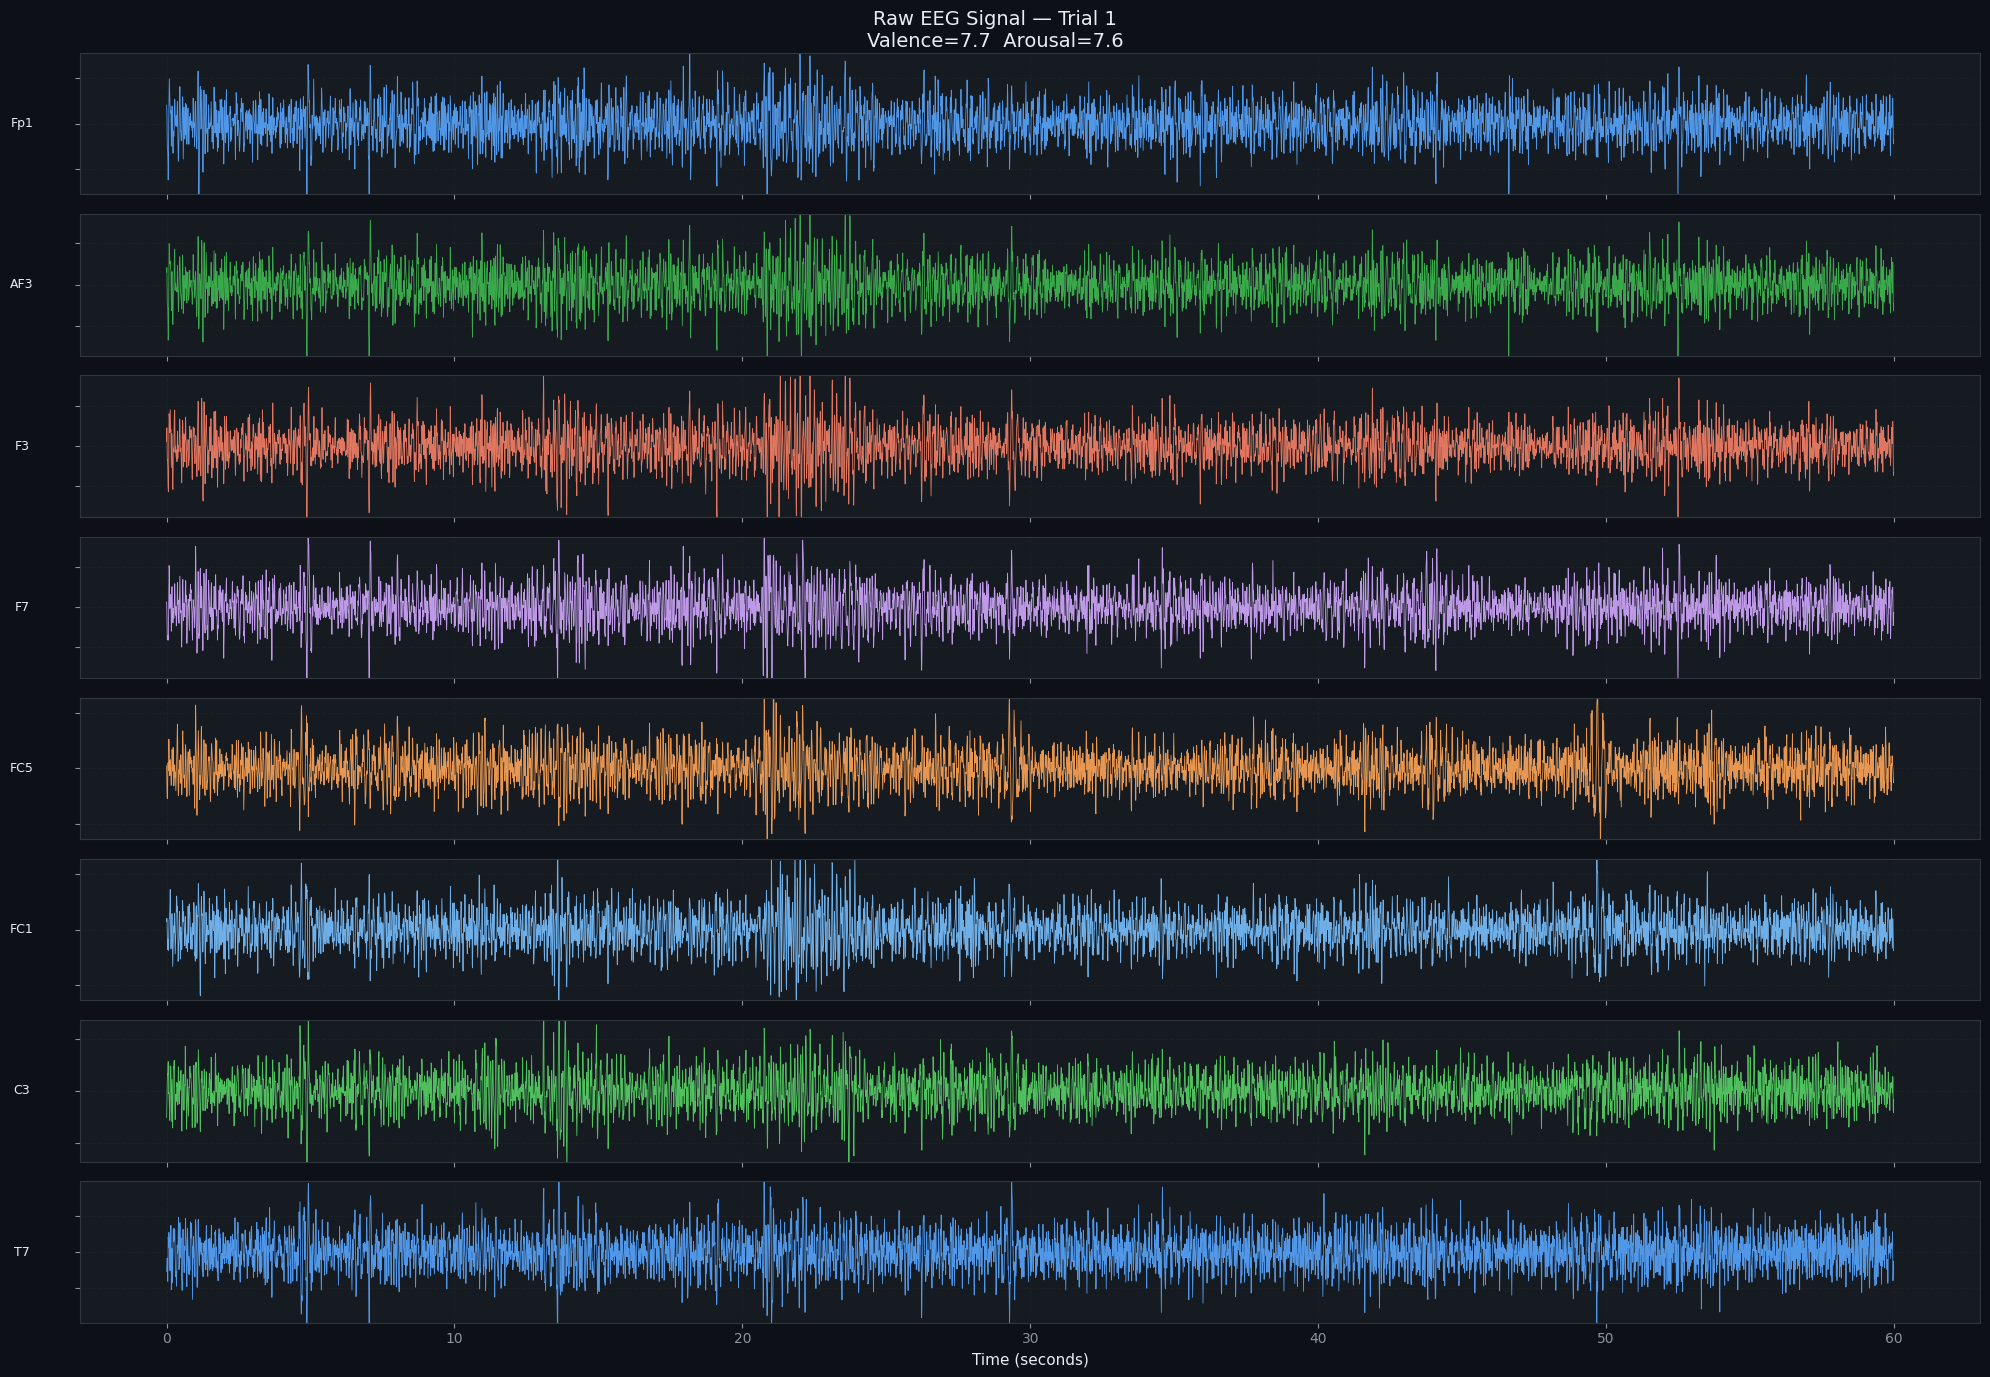

In [8]:
trial_idx = 0   # change to inspect different trials
n_channels_to_show = 8
time_axis = np.arange(data.shape[2]) / SRATE

fig, axes = plt.subplots(n_channels_to_show, 1, figsize=(20, 14), sharex=True)
fig.suptitle(f'Raw EEG Signal — Trial {trial_idx+1}\n'
             f'Valence={labels[trial_idx,0]:.1f}  Arousal={labels[trial_idx,1]:.1f}',
             fontsize=14, color='#e6edf3')

for i, ax in enumerate(axes):
    ch_data = data[trial_idx, i, :]
    ax.plot(time_axis, ch_data, color=PALETTE[i % len(PALETTE)], lw=0.6, alpha=0.9)
    ax.set_ylabel(CHANNEL_NAMES[i], fontsize=9, rotation=0, labelpad=35, va='center')
    ax.set_ylim(ch_data.mean()-4*ch_data.std(), ch_data.mean()+4*ch_data.std())
    ax.yaxis.set_ticklabels([])

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.savefig('eda_raw_eeg.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

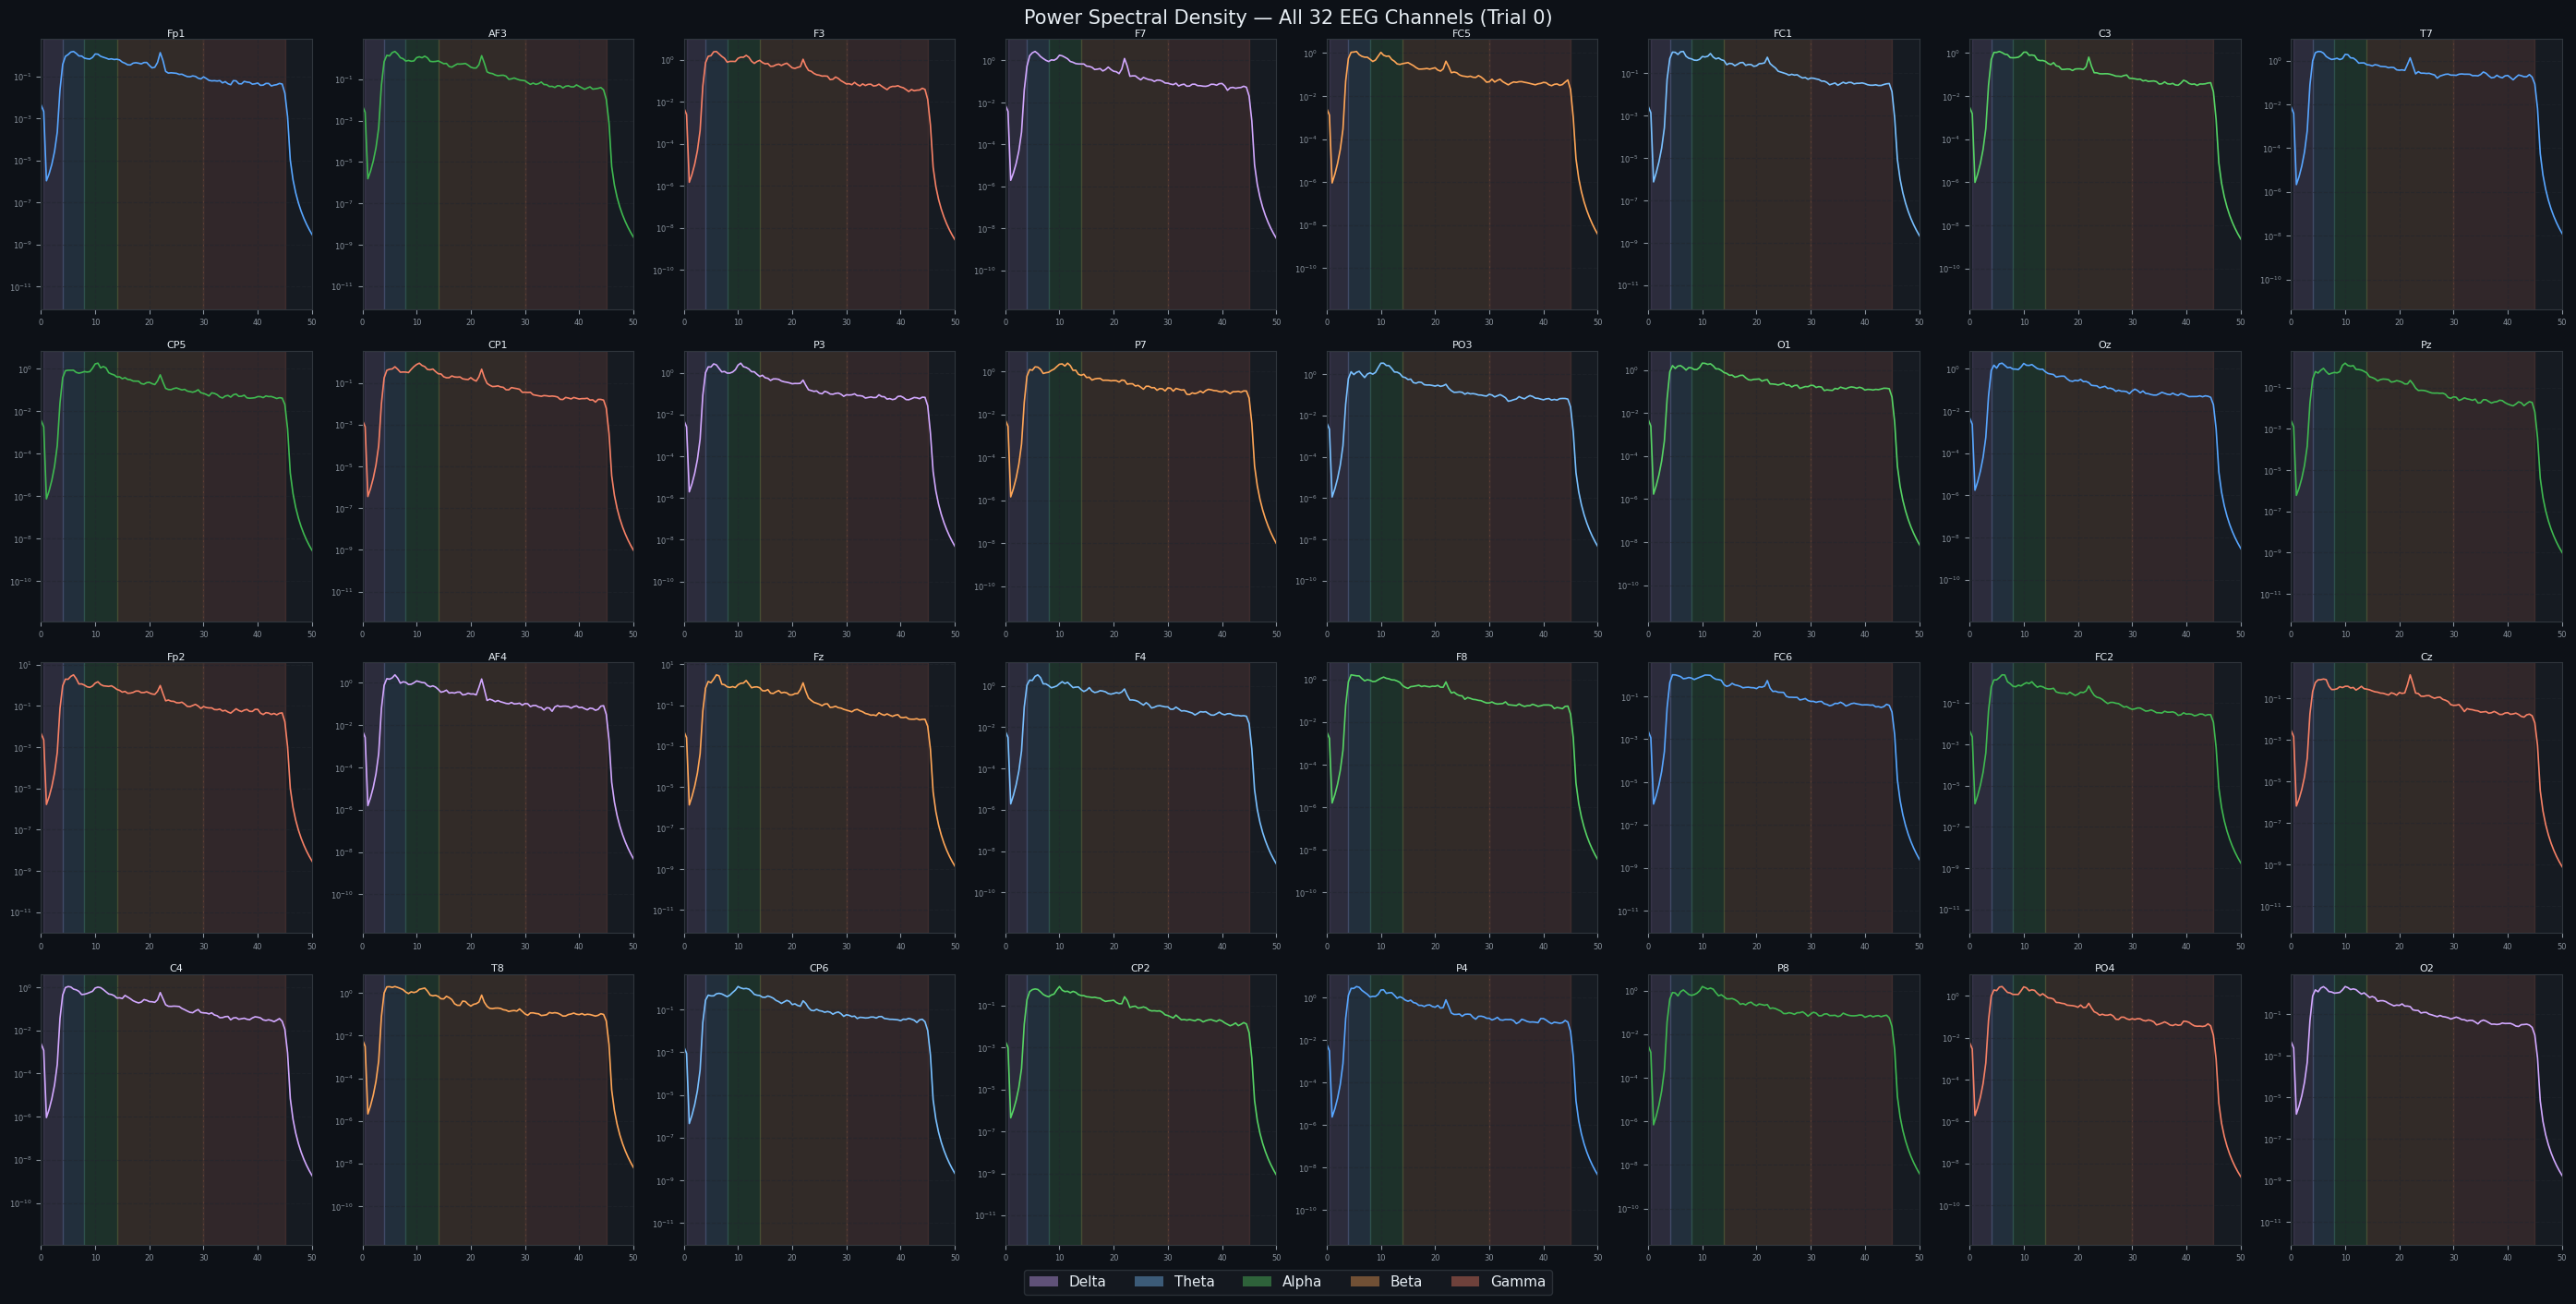

In [9]:
fig, axes = plt.subplots(4, 8, figsize=(28, 14))
fig.suptitle('Power Spectral Density — All 32 EEG Channels (Trial 0)', fontsize=15)
axes = axes.flatten()

band_colors = {'Delta':'#d2a8ff','Theta':'#79c0ff','Alpha':'#56d364','Beta':'#ffa657','Gamma':'#f78166'}

for i, ax in enumerate(axes):
    freqs, psd = welch(data[trial_idx, i, :], fs=SRATE, nperseg=256)
    ax.semilogy(freqs, psd, color=PALETTE[i%len(PALETTE)], lw=1.2)

    # Shade frequency bands
    for band, (lo, hi) in BANDS.items():
        ax.axvspan(lo, hi, alpha=0.12, color=band_colors[band])

    ax.set_xlim(0, 50)
    ax.set_title(CHANNEL_NAMES[i], fontsize=8, pad=2)
    ax.set_xlabel('', fontsize=7)
    ax.set_ylabel('', fontsize=7)
    ax.tick_params(labelsize=6)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.4, label=b)
                   for b, c in band_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('eda_psd.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

Computing cross-channel correlations across all trials...


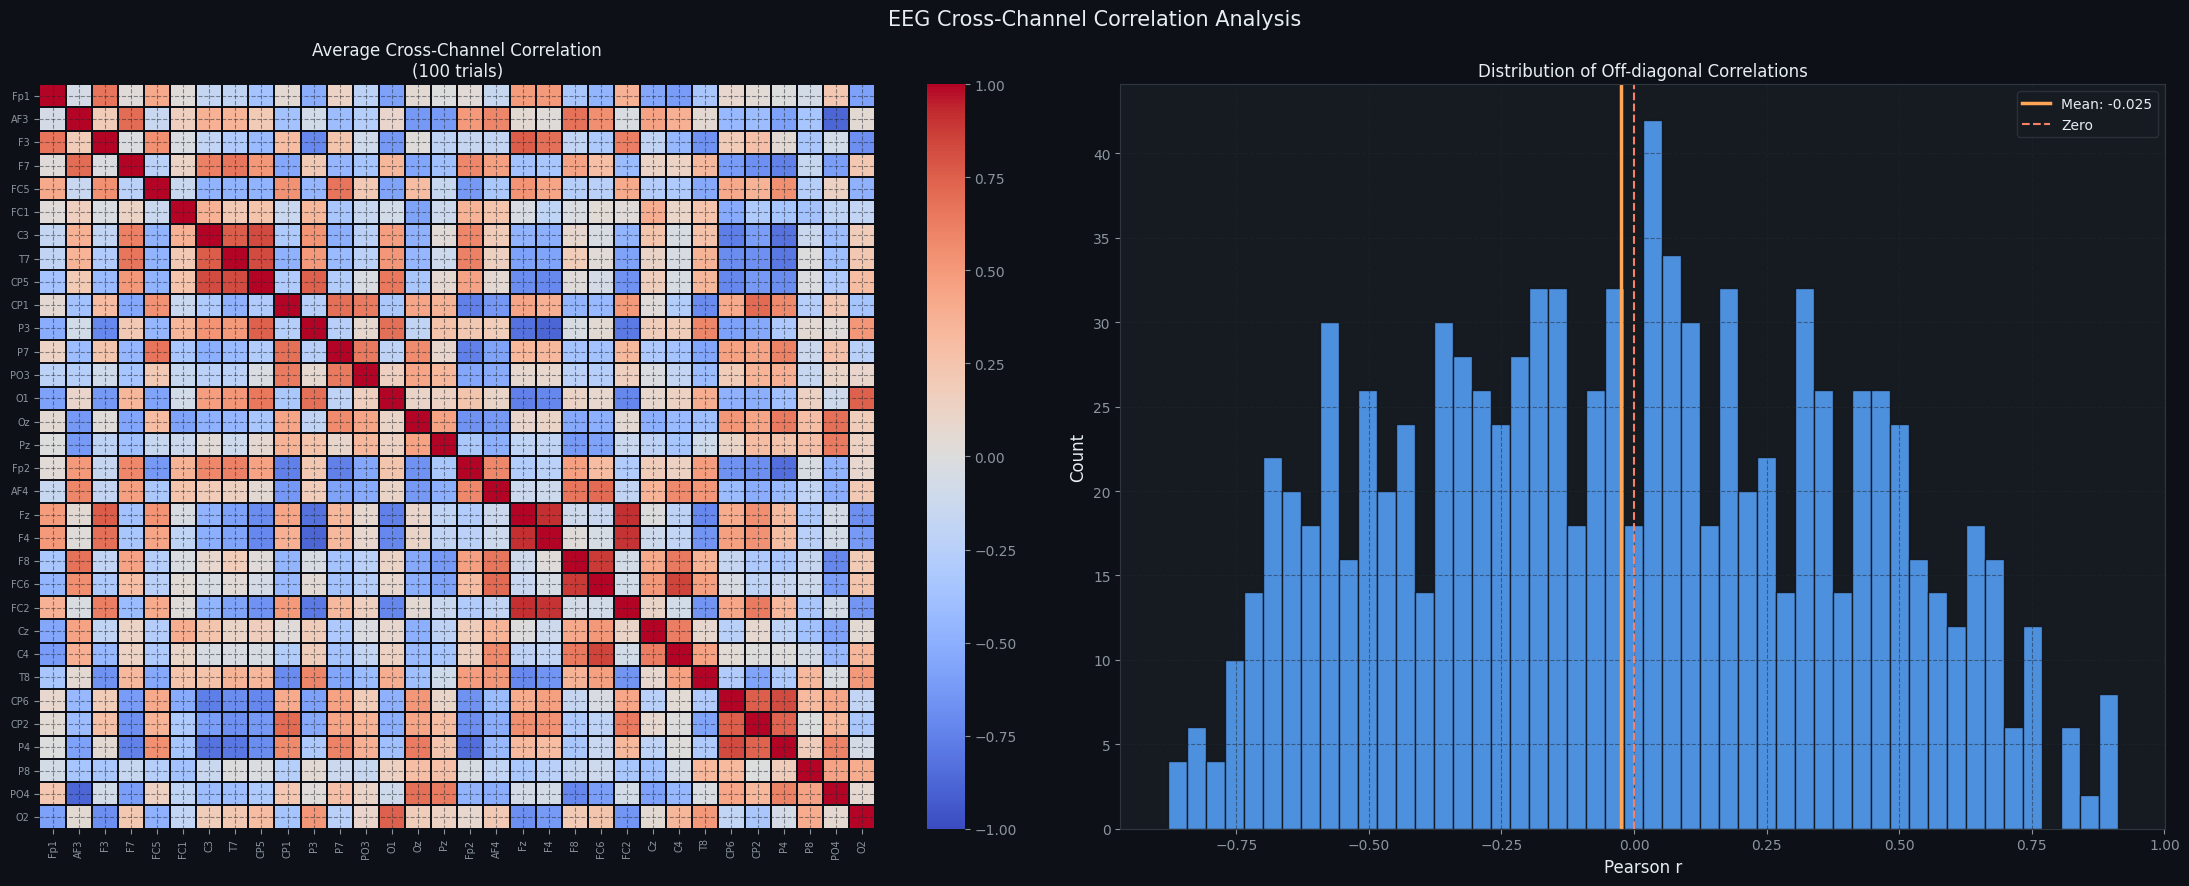

In [11]:
def bandpass_filter(data_ch, lowcut=4.0, highcut=45.0, fs=128, order=5):
    """4th-order Butterworth bandpass filter (4–45 Hz)"""
    nyq  = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data_ch)


def notch_filter(data_ch, notch_freq=50.0, fs=128, quality=30):
    """Notch filter to remove 50 Hz power-line interference"""
    b, a = iirnotch(notch_freq / (0.5 * fs), quality)
    return filtfilt(b, a, data_ch)


def preprocess_eeg(raw_data, fs=128):
    """
    Full preprocessing pipeline:
      1. Bandpass filter  4–45 Hz
      2. Notch filter     50 Hz
      3. Z-score normalize each channel independently
    """
    N, C, T = raw_data.shape
    processed = np.zeros_like(raw_data, dtype=np.float32)
    for n in tqdm(range(N), desc='Preprocessing trials', leave=False):
        for c in range(C):
            ch = raw_data[n, c, :].copy().astype(np.float64)
            ch = bandpass_filter(ch, 4.0, 45.0, fs)
            ch = notch_filter(ch, 50.0, fs)
            # Z-score normalization
            ch = (ch - ch.mean()) / (ch.std() + 1e-8)
            processed[n, c, :] = ch.astype(np.float32)
    return processed


print("⚙️  Preprocessing all trials...")
data_clean = preprocess_eeg(data)
print(f"✅ Preprocessing complete — shape: {data_clean.shape}")

⚙️  Preprocessing all trials...


Preprocessing trials:   0%|          | 0/1280 [00:00<?, ?it/s]

✅ Preprocessing complete — shape: (1280, 32, 7680)


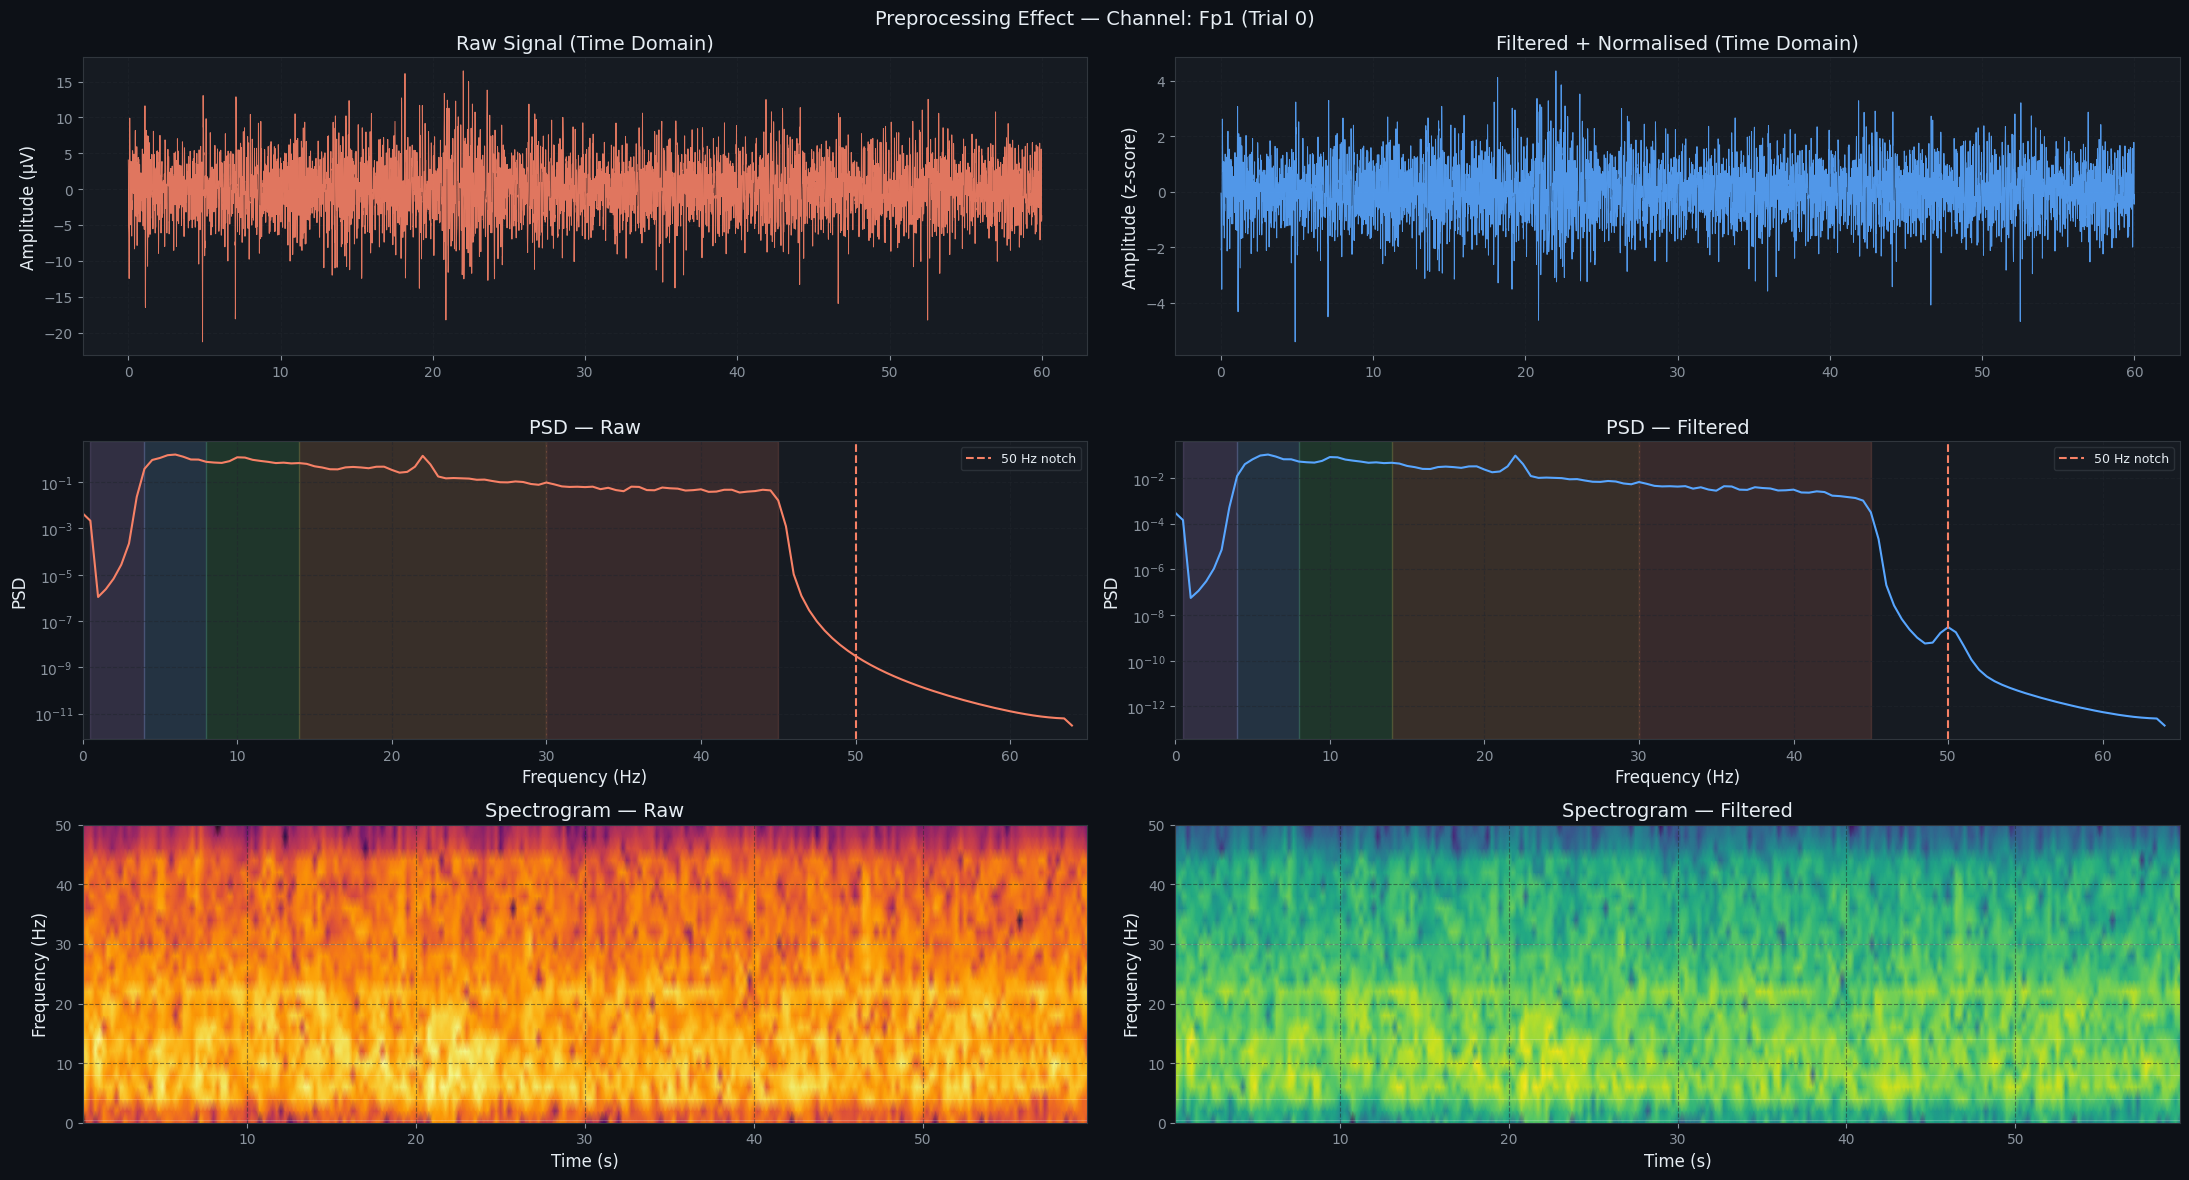

In [12]:
ch_idx = 0  # Fp1
t = np.arange(data.shape[2]) / SRATE

fig, axes = plt.subplots(3, 2, figsize=(22, 12))
fig.suptitle(f'Preprocessing Effect — Channel: {CHANNEL_NAMES[ch_idx]} (Trial 0)',
             fontsize=14, color='#e6edf3')

raw = data[0, ch_idx, :].astype(np.float64)
clean = data_clean[0, ch_idx, :]

# Time domain
axes[0,0].plot(t, raw, color=PALETTE[2], lw=0.7, alpha=0.9)
axes[0,0].set_title('Raw Signal (Time Domain)')
axes[0,0].set_ylabel('Amplitude (μV)')

axes[0,1].plot(t, clean, color=PALETTE[0], lw=0.7, alpha=0.9)
axes[0,1].set_title('Filtered + Normalised (Time Domain)')
axes[0,1].set_ylabel('Amplitude (z-score)')

# Frequency domain (PSD)
for ax, sig, title, col in [
    (axes[1,0], raw,   'PSD — Raw',     PALETTE[2]),
    (axes[1,1], clean, 'PSD — Filtered', PALETTE[0])
]:
    f, p = welch(sig, fs=SRATE, nperseg=256)
    ax.semilogy(f, p, color=col, lw=1.5)
    for band, (lo, hi) in BANDS.items():
        ax.axvspan(lo, hi, alpha=0.15, color=band_colors[band])
    ax.axvline(50, color='#f78166', lw=1.5, linestyle='--', label='50 Hz notch')
    ax.set_xlim(0, 65)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title(title)
    ax.legend(fontsize=9)

# Spectrogram
for ax, sig, title, col in [
    (axes[2,0], raw,   'Spectrogram — Raw',     'inferno'),
    (axes[2,1], clean, 'Spectrogram — Filtered', 'viridis')
]:
    f, t_spec, Sxx = signal.spectrogram(sig, fs=SRATE, nperseg=64, noverlap=32)
    ax.pcolormesh(t_spec, f[f<=50], 10*np.log10(Sxx[f<=50]+1e-10),
                  shading='gouraud', cmap=col)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_title(title)
    for _, (lo, hi) in BANDS.items():
        ax.axhline(lo, color='white', lw=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [14]:
def compute_band_power(ch_data, fs=128):
    """Compute average PSD power in each EEG frequency band."""
    freqs, psd = welch(ch_data, fs=fs, nperseg=min(256, len(ch_data)))
    powers = {}
    for band, (lo, hi) in BANDS.items():
        idx = np.logical_and(freqs >= lo, freqs <= hi)
        powers[band] = np.trapz(psd[idx], freqs[idx])
    return powers


def hjorth_params(ch_data):
    """Hjorth activity, mobility, complexity."""
    diff1 = np.diff(ch_data)
    diff2 = np.diff(diff1)
    activity   = np.var(ch_data)
    mobility   = np.sqrt(np.var(diff1) / (np.var(ch_data) + 1e-10))
    complexity = (np.sqrt(np.var(diff2) / (np.var(diff1) + 1e-10))) / (mobility + 1e-10)
    return activity, mobility, complexity


def extract_features(eeg_data, fs=128):
    """
    Extract comprehensive feature vector per trial.
    eeg_data: (n_trials, n_channels, n_timepoints)
    returns : (n_trials, n_features)
    """
    N, C, T = eeg_data.shape
    feature_matrix = []

    for trial_i in tqdm(range(N), desc='Extracting features'):
        feat_vec = []
        band_powers_all = []  # shape (C, 5)

        for ch in range(C):
            sig = eeg_data[trial_i, ch, :]

            # ── Band Powers ───────────────────────────────────────────────────
            bp = compute_band_power(sig, fs)
            band_powers_all.append(list(bp.values()))
            feat_vec.extend(list(bp.values()))

            # ── Statistical Features ──────────────────────────────────────────
            feat_vec.append(np.mean(sig))
            feat_vec.append(np.std(sig))
            feat_vec.append(float(skew(sig)))
            feat_vec.append(float(kurtosis(sig)))
            feat_vec.append(np.sum(sig**2) / T)   # signal energy

            # ── Hjorth Parameters ─────────────────────────────────────────────
            act, mob, comp = hjorth_params(sig)
            feat_vec.extend([act, mob, comp])

        # ── Differential Asymmetry (DASM) — frontal alpha ─────────────────────
        # Pairs: (left, right) in DEAP 10-20 mapping
        # Alpha band index = 2 in BANDS dict
        dasm_pairs = [(0,16),(1,17),(2,19),(3,20),(4,21),(5,22),(6,24),(7,25)]
        bp_arr = np.array(band_powers_all)  # (32, 5)
        alpha_idx = list(BANDS.keys()).index('Alpha')
        for L, R in dasm_pairs:
            feat_vec.append(bp_arr[L, alpha_idx] - bp_arr[R, alpha_idx])  # DASM
            r_right = bp_arr[R, alpha_idx] + 1e-10
            feat_vec.append(bp_arr[L, alpha_idx] / r_right)               # RASM

        feature_matrix.append(feat_vec)

    return np.array(feature_matrix, dtype=np.float32)


print("⚙️  Extracting features from all trials...")
X_features = extract_features(data_clean)
print(f"✅ Feature matrix shape: {X_features.shape}")
print(f"   {X_features.shape[1]} features per trial")

⚙️  Extracting features from all trials...


Extracting features:   0%|          | 0/1280 [00:00<?, ?it/s]

✅ Feature matrix shape: (1280, 432)
   432 features per trial


Target: VALENCE (binary)
Class distribution — 0 (Low): 556  |  1 (High): 724
Class balance     : 43.4% / 56.6%


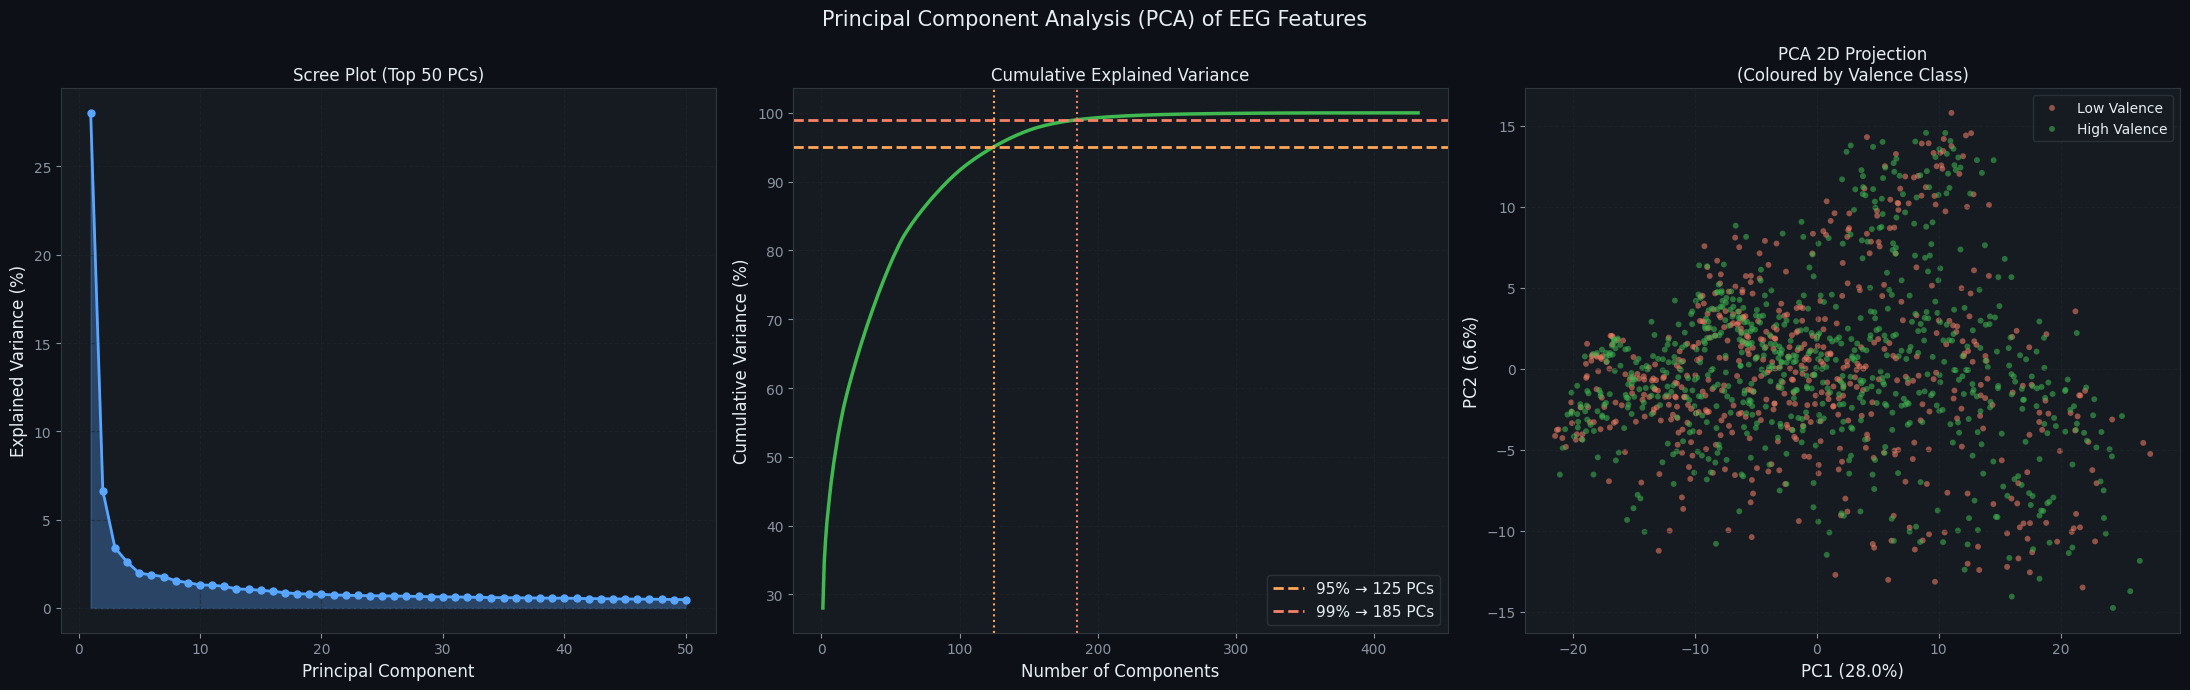


📊 PCA Summary:
   Original features  : 432
   PCs for 95% var    : 125
   PCs for 99% var    : 185
   Reduced X_pca shape: (1280, 125)


⚙️  Running t-SNE (this may take ~1 min)...


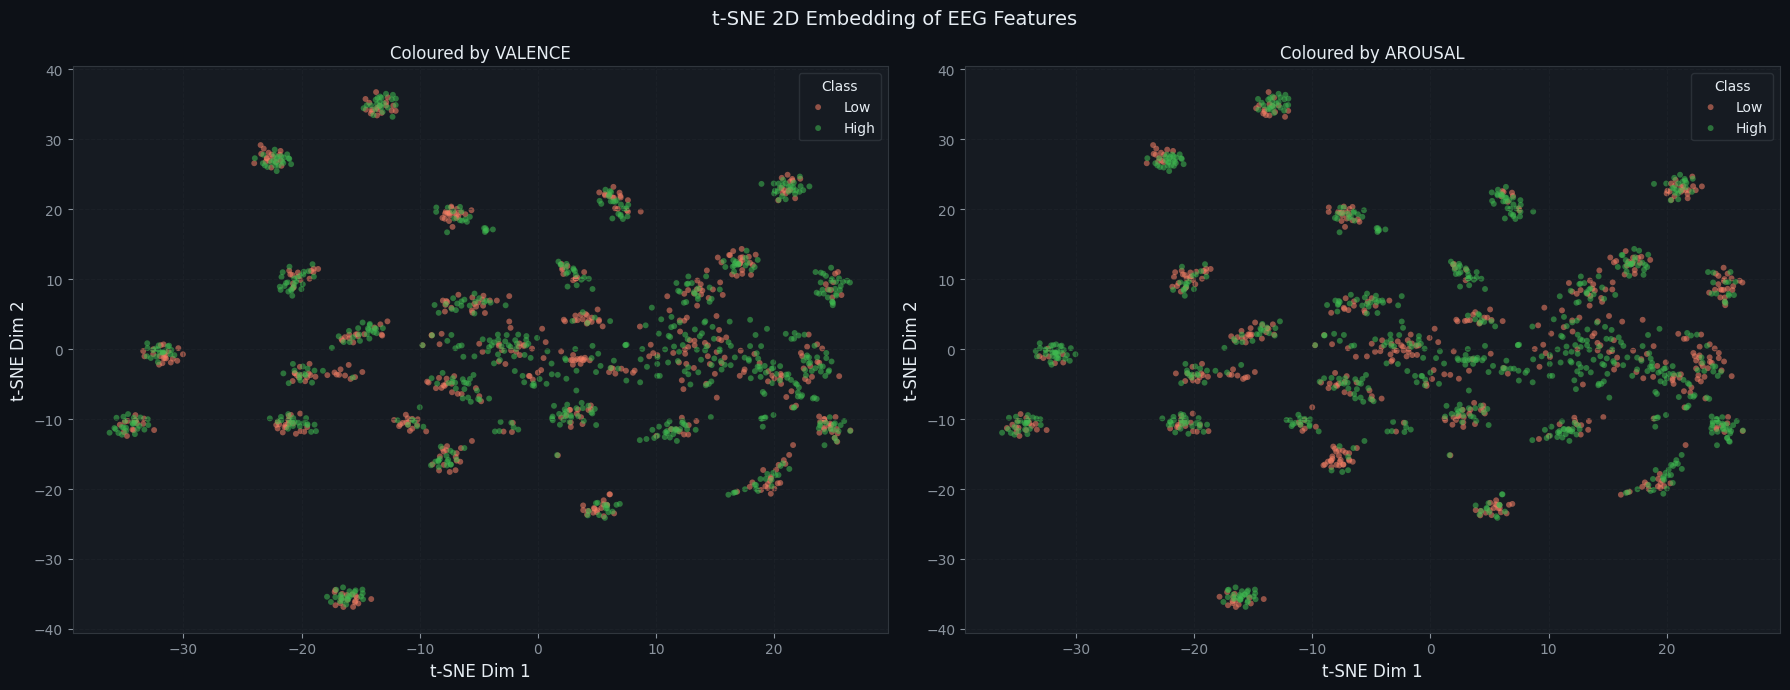

In [17]:
print("⚙️  Running t-SNE (this may take ~1 min)...")
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            learning_rate='auto', random_state=SEED)
X_tsne = tsne.fit_transform(X_pca[:, :50])  # feed top-50 PCs for speed

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE 2D Embedding of EEG Features', fontsize=14)

for ax, label_arr, title in [
    (axes[0], y_val, 'Coloured by VALENCE'),
    (axes[1], y_aro, 'Coloured by AROUSAL')
]:
    for cls, col, lbl in [(0, PALETTE[2], 'Low'), (1, PALETTE[1], 'High')]:
        mask = label_arr == cls
        ax.scatter(X_tsne[mask,0], X_tsne[mask,1],
                   c=col, alpha=0.55, s=18, label=lbl, edgecolors='none')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.legend(title='Class', fontsize=10)

plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

⚙️  Fitting Random Forest for feature importance...


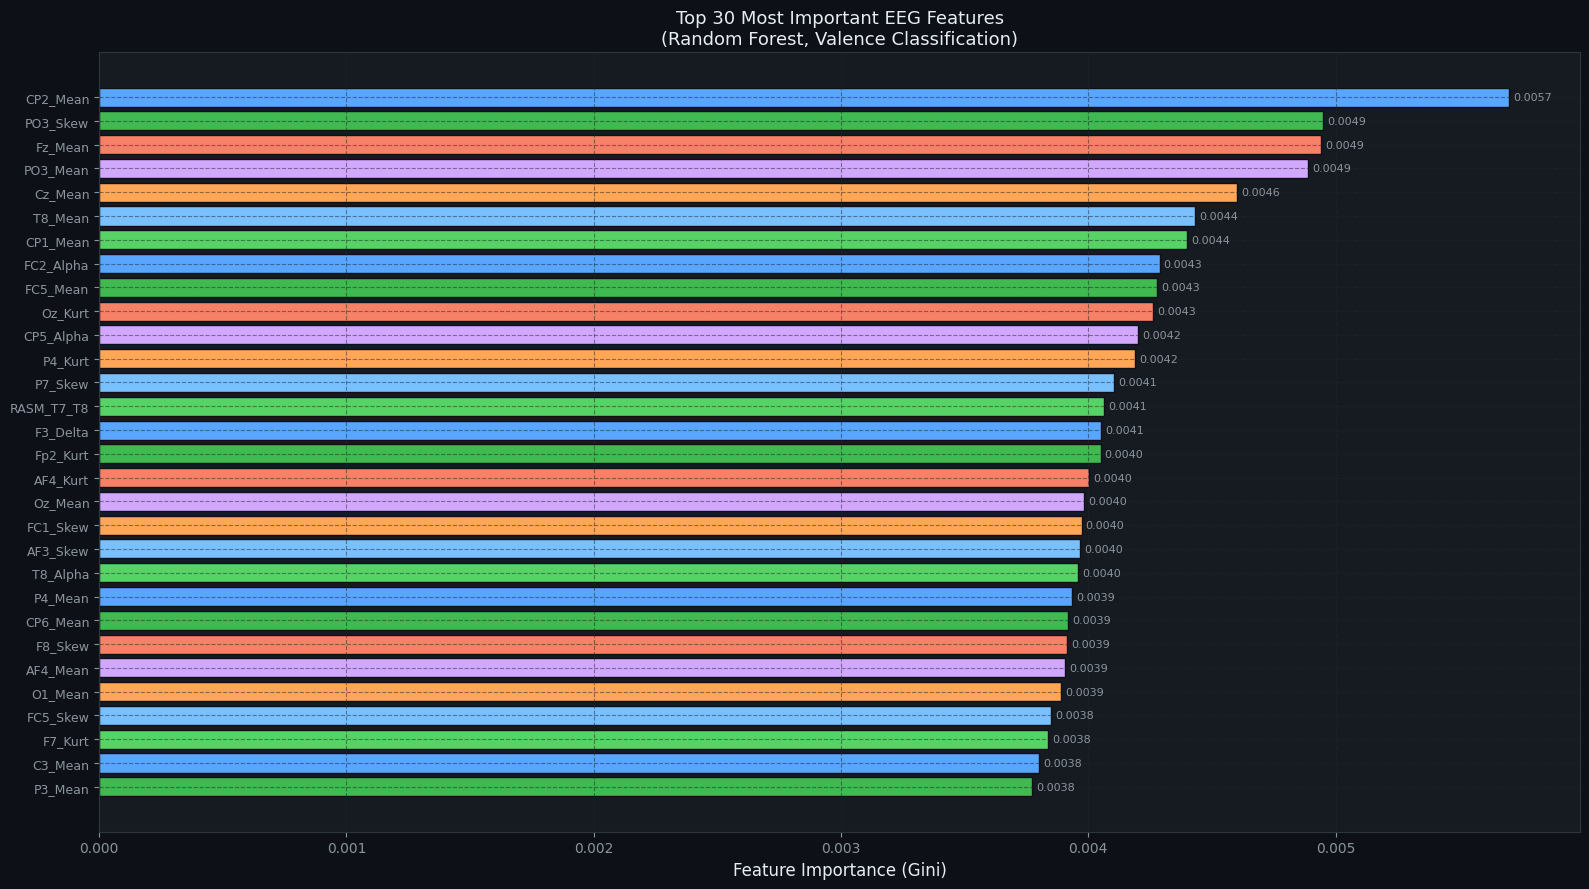

Dataset splits:
  Feature-based → Train: (870, 125)  Val: (154, 125)  Test: (256, 125)
  Deep Learning → Train: (870, 512, 32)  Val: (154, 512, 32)  Test: (256, 512, 32)


In [22]:
results = {}

def train_eval_classical(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred  = clf.predict(X_te)
    y_prob  = clf.predict_proba(X_te)[:,1] if hasattr(clf, 'predict_proba') else None
    acc     = accuracy_score(y_te, y_pred)
    f1      = f1_score(y_te, y_pred, average='weighted')
    auc_sc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    
    # --- FIX IS HERE ---
    # Determine the display string for AUC before the print statement
    auc_display = f"{auc_sc:.4f}" if auc_sc is not None else "N/A"
    
    print(f"  {name:<20} Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc_display}")
    # -------------------
    
    results[name] = {'acc': acc, 'f1': f1, 'auc': auc_sc, 'clf': clf,
                     'y_pred': y_pred, 'y_prob': y_prob}
    return clf

print("\n🔥 Training Classical ML Models...\n")
print(f"{'Model':<20} {'Accuracy':>10}  {'F1-Score':>10}  {'AUC-ROC':>10}")
print("-"*55)

# SVM
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
train_eval_classical('SVM (RBF)', svm, X_tr, y_tr, X_te, y_te)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=SEED, n_jobs=-1)
train_eval_classical('Random Forest', rf, X_tr, y_tr, X_te, y_te)

# XGBoost
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                         use_label_encoder=False, eval_metric='logloss',
                         random_state=SEED, n_jobs=-1)
    train_eval_classical('XGBoost', xgb, X_tr, y_tr, X_te, y_te)



🔥 Training Classical ML Models...

Model                  Accuracy    F1-Score     AUC-ROC
-------------------------------------------------------
  SVM (RBF)            Acc: 0.5430  F1: 0.5402  AUC: 0.5305
  Random Forest        Acc: 0.5430  F1: 0.4770  AUC: 0.4892
  XGBoost              Acc: 0.5703  F1: 0.5569  AUC: 0.5517


In [23]:
def build_cnn1d(input_shape, n_classes=2):
    """
    1D-CNN for EEG temporal feature extraction.
    Input: (timesteps, n_channels)
    """
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv1D(64, kernel_size=7, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Block 2
        Conv1D(128, kernel_size=5, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Block 3
        Conv1D(256, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dropout(0.4),

        # Dense head
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dense(1 if n_classes == 2 else n_classes,
              activation='sigmoid' if n_classes == 2 else 'softmax')
    ], name='CNN_1D')
    return model


CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

cnn_model = build_cnn1d(input_shape=X_tr_dl.shape[1:])
cnn_model.compile(optimizer=Adam(1e-3),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
cnn_model.summary()

print("\n🏋️ Training 1D-CNN...")
hist_cnn = cnn_model.fit(
    X_tr_dl, y_tr_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=100, batch_size=64,
    callbacks=CALLBACKS, verbose=1
)

I0000 00:00:1775662705.175302      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 512, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,569 (771.75 KB)

 Trainable params: 196,417 (767.25 KB)

...


🏋️ Training 1D-CNN...
Epoch 1/100


2026-04-08 15:38:26.727560: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1775662710.056271     234 cuda_dnn.cc:529] Loaded cuDNN version 91002


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5402 - loss: 0.7850

2026-04-08 15:38:33.120036: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5405 - loss: 0.7860 - val_accuracy: 0.5649 - val_loss: 0.7128 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5653 - loss: 0.7567 - val_accuracy: 0.5779 - val_loss: 0.7050 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5796 - loss: 0.7187 - val_accuracy: 0.5779 - val_loss: 0.7073 - learning_rate: 0.0010
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6189 - loss: 0.6748 - val_accuracy: 0.5779 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6266 - loss: 0.6870 - val_accuracy: 0.5714 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6091 - loss: 0.6797 - val_accuracy: 0.5649 - val_loss: 0.7019 - learning_rate: 0.0010
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6422 - loss: 0.6545 - val_accuracy

In [25]:
def build_bilstm(input_shape, n_classes=2):
    """
    Bidirectional LSTM — captures temporal dependencies
    in both directions across the EEG time series.
    """
    model = Sequential([
        Input(shape=input_shape),

        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        BatchNormalization(),

        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)),
        BatchNormalization(),

        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='Bi_LSTM')
    return model


bilstm_model = build_bilstm(input_shape=X_tr_dl.shape[1:])
bilstm_model.compile(optimizer=Adam(5e-4),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
bilstm_model.summary()

print("\n🏋️ Training Bi-LSTM...")
hist_bilstm = bilstm_model.fit(
    X_tr_dl, y_tr_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=10, batch_size=64,
    callbacks=CALLBACKS, verbose=1
)

Model: "Bi_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 512, 256)       │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,585 (1.36 MB)

 Trainable params: 354,817 (1.35 MB)

 Non-trainable params: 768 (3.00 KB)


🏋️ Training Bi-LSTM...
Epoch 1/10


2026-04-08 15:41:29.309887: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4929 - loss: 0.7956

2026-04-08 15:42:35.469233: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


14/14 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.4924 - loss: 0.7965 - val_accuracy: 0.5649 - val_loss: 0.7038 - learning_rate: 5.0000e-04
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5252 - loss: 0.7652 - val_accuracy: 0.5779 - val_loss: 0.7022 - learning_rate: 5.0000e-04
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5280 - loss: 0.7357 - val_accuracy: 0.5974 - val_loss: 0.7011 - learning_rate: 5.0000e-04
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5565 - loss: 0.7221 - val_accuracy: 0.5649 - val_loss: 0.7008 - learning_rate: 5.0000e-04
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5590 - loss: 0.7138 - val_accuracy: 0.5714 - val_loss: 0.7000 - learning_rate: 5.0000e-04
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.5659 - loss: 0.7110 - val_accuracy: 0.5649 - val_loss: 0.6989 - learning_rate: 5.0000e-04
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5440 - loss: 0.7514 - v

In [39]:
def build_cnn_lstm_attention(input_shape, n_classes=2):
    """
    CNN-LSTM with Multi-Head Self-Attention.
    Architecture:
      [Input] → CNN blocks (spatial/local patterns)
             → Bi-LSTM (temporal dependencies)
             → Multi-Head Attention (focus mechanism)
             → Dense head
             → [Output]
    """
    inputs = Input(shape=input_shape, name='eeg_input')

    # ── CNN Feature Extraction ──────────────────────────────────────────────────
    x = Conv1D(64,  kernel_size=7, padding='same', activation='relu', name='conv1')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Conv1D(128, kernel_size=5, padding='same', activation='relu', name='conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Conv1D(256, kernel_size=3, padding='same', activation='relu', name='conv3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.25)(x)

    # ── Bi-LSTM Temporal Modelling ──────────────────────────────────────────────
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3), name='bilstm1')(x)
    x = LayerNormalization()(x)

    x = Bidirectional(LSTM(64,  return_sequences=True, dropout=0.25), name='bilstm2')(x)
    x = LayerNormalization()(x)

    # ── Multi-Head Self-Attention ───────────────────────────────────────────────
    attn_out = MultiHeadAttention(num_heads=4, key_dim=32, name='mh_attention')(x, x)
    x = Add()([x, attn_out])                   # Residual connection
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)

    # ── Dense Classifier Head ───────────────────────────────────────────────────
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)

    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name='CNN_LSTM_Attention')
    return model


best_model = build_cnn_lstm_attention(input_shape=X_tr_dl.shape[1:])
best_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
best_model.summary()

callbacks_best = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_eeg_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("\n🏋️ Training CNN-LSTM-Attention (Best Model)...")
hist_best = best_model.fit(
    X_tr_dl, y_tr_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50, batch_size=32,
    callbacks=callbacks_best, verbose=1
)

Model: "CNN_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 512, 32)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 512, 64)   │     14,400 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 64)   │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 512, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 512, 128)  │     41,088 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 128)  │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 256, 128)  │          0 │ max_pooling1d_6[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 256, 256)  │     98,560 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256)  │      1,024 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 128, 256)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 128, 256)  │          0 │ max_pooling1d_7[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm1             │ (None, 128, 256)  │    394,240 │ dropout_22[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ bilstm1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm2             │ (None, 128, 128)  │    164,352 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ bilstm2[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mh_attention        │ (None, 128, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 128)  │          0 │ layer_normalizat

 Total params: 857,281 (3.27 MB)

 Trainable params: 855,617 (3.26 MB)

 Non-trainable params: 1,664 (6.50 KB)

...


Epoch 1: val_accuracy improved from -inf to 0.48052, saving model to best_eeg_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.5087 - loss: 0.8738 - val_accuracy: 0.4805 - val_loss: 0.7277 - learning_rate: 5.0000e-04
Epoch 2/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5495 - loss: 0.7748
Epoch 2: val_accuracy improved from 0.48052 to 0.53896, saving model to best_eeg_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5482 - loss: 0.7758 - val_accuracy: 0.5390 - val_loss: 0.7267 - learning_rate: 5.0000e-04
Epoch 3/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5518 - loss: 0.7730
Epoch 3: val_accuracy did not improve from 0.53896
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5507 - loss: 0.7736 - val_accuracy: 0.4610 - val_loss: 0.7481 - learning_rate: 5.0000e-04
Epoch 4/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5392 - loss: 0.7763
Epoch 4: val_accuracy improved from 0.53896 to 0.55195, saving model to best_eeg_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5390 - loss: 0.7765 - val_accuracy: 0.5519 - val_loss: 0.7250 - learning_rate: 5.0000e-04
Epoch 5/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4938 - loss: 0.7946
Epoch 5: val_accuracy did not improve from 0.55195
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.4938 - loss: 0.7949 - val_accuracy: 0.5519 - val_loss: 0.7284 - learning_rate: 5.0000e-04
Epoch 6/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5427 - loss: 0.7524
Epoch 6: val_accuracy did not improve from 0.55195
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5420 - loss: 0.7532 - val_accuracy: 0.5519 - val_loss: 0.7301 - learning_rate: 5.0000e-04
Epoch 7/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5533 - loss: 0.7707
Epoch 7: val_accuracy did not improve from 0.55195
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5533 - loss: 0.7705 - val_accuracy: 0.5455 - val_loss: 0.7450 - learning_rate: 5.0000e-04
Epoch 8/50
27/28

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5395 - loss: 0.7552 - val_accuracy: 0.5649 - val_loss: 0.7333 - learning_rate: 5.0000e-04
Epoch 9/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5827 - loss: 0.7254
Epoch 9: val_accuracy did not improve from 0.56494
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5805 - loss: 0.7271 - val_accuracy: 0.5519 - val_loss: 0.7346 - learning_rate: 5.0000e-04
Epoch 10/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5379 - loss: 0.7529
Epoch 10: val_accuracy did not improve from 0.56494
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5378 - loss: 0.7531 - val_accuracy: 0.5325 - val_loss: 0.7921 - learning_rate: 5.0000e-04
Epoch 11/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5495 - loss: 0.7616
Epoch 11: val_accuracy did not improve from 0.56494
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5491 - loss: 0.7610 - val_accuracy: 0.4481 - val_loss: 0.7787 - learning_rate: 5.0000e-04
Epoch 12/50


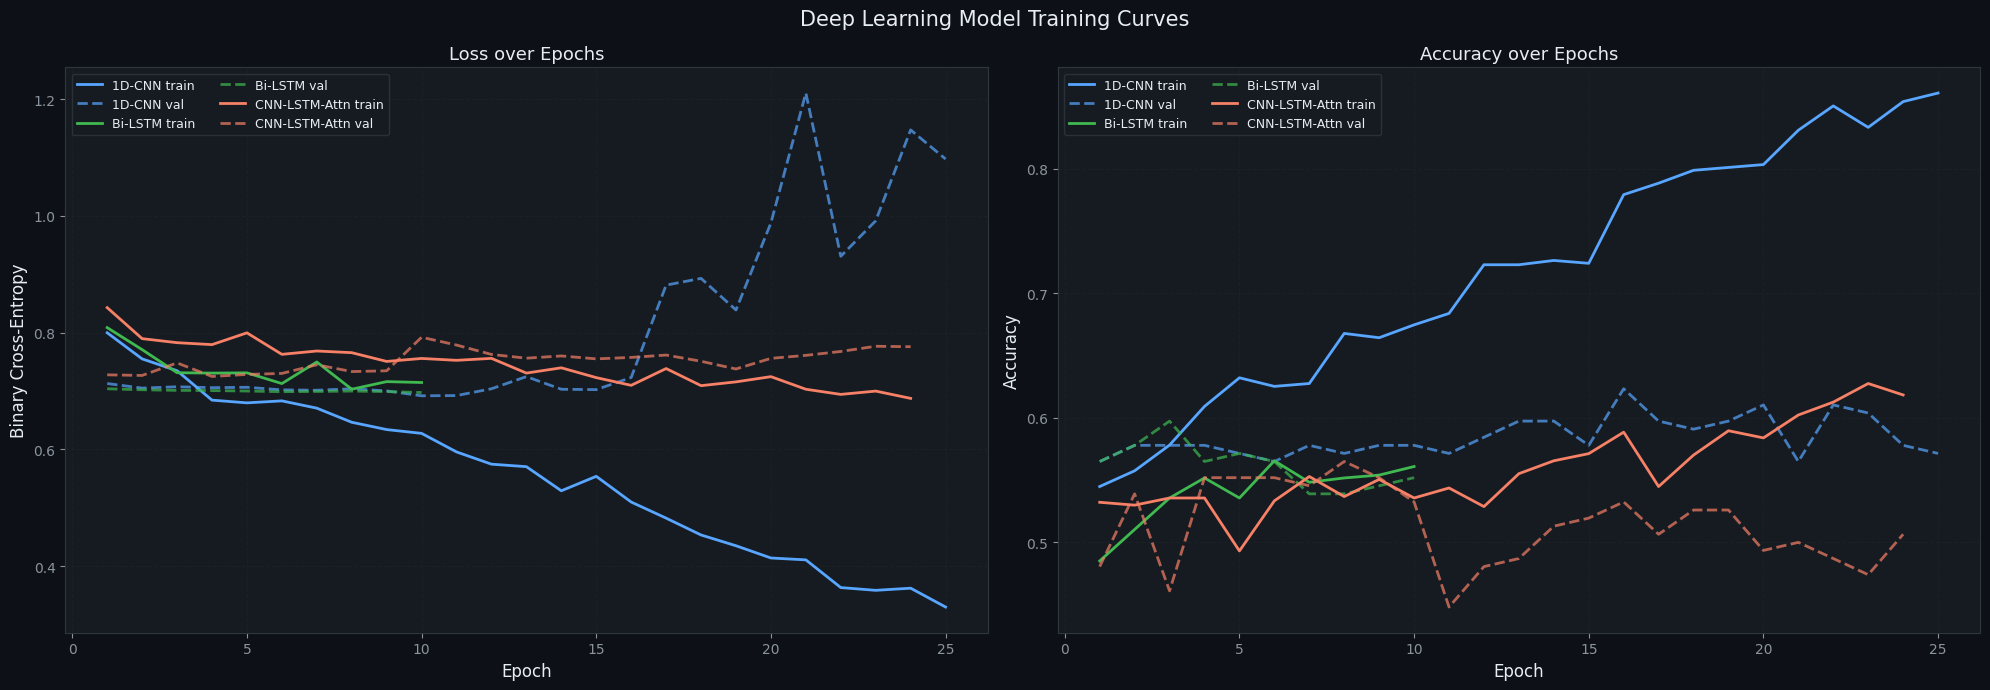

In [40]:
def plot_training_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle('Deep Learning Model Training Curves', fontsize=15)

    for hist, name, col in zip(histories, names, PALETTE):
        h = hist.history
        eps = range(1, len(h['loss'])+1)

        axes[0].plot(eps, h['loss'],     color=col, lw=2,   label=f'{name} train')
        axes[0].plot(eps, h['val_loss'], color=col, lw=2,
                     linestyle='--', alpha=0.7, label=f'{name} val')

        axes[1].plot(eps, h['accuracy'],     color=col, lw=2,   label=f'{name} train')
        axes[1].plot(eps, h['val_accuracy'], color=col, lw=2,
                     linestyle='--', alpha=0.7, label=f'{name} val')

    for ax, title, ylabel in [
        (axes[0], 'Loss over Epochs',    'Binary Cross-Entropy'),
        (axes[1], 'Accuracy over Epochs','Accuracy')
    ]:
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9, ncol=2)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()


plot_training_history(
    [hist_cnn, hist_bilstm, hist_best],
    ['1D-CNN', 'Bi-LSTM', 'CNN-LSTM-Attn']
)


════════════════════════════════════════════════════════════
  TEST SET PERFORMANCE
════════════════════════════════════════════════════════════
  Model                       Accuracy        F1       AUC
------------------------------------------------------------
  1D-CNN                    Acc: 0.5547  F1: 0.4774  AUC: 0.5491
  Bi-LSTM                   Acc: 0.5352  F1: 0.4481  AUC: 0.4618
  CNN-LSTM-Attention ★      Acc: 0.5352  F1: 0.5113  AUC: 0.5110
════════════════════════════════════════════════════════════


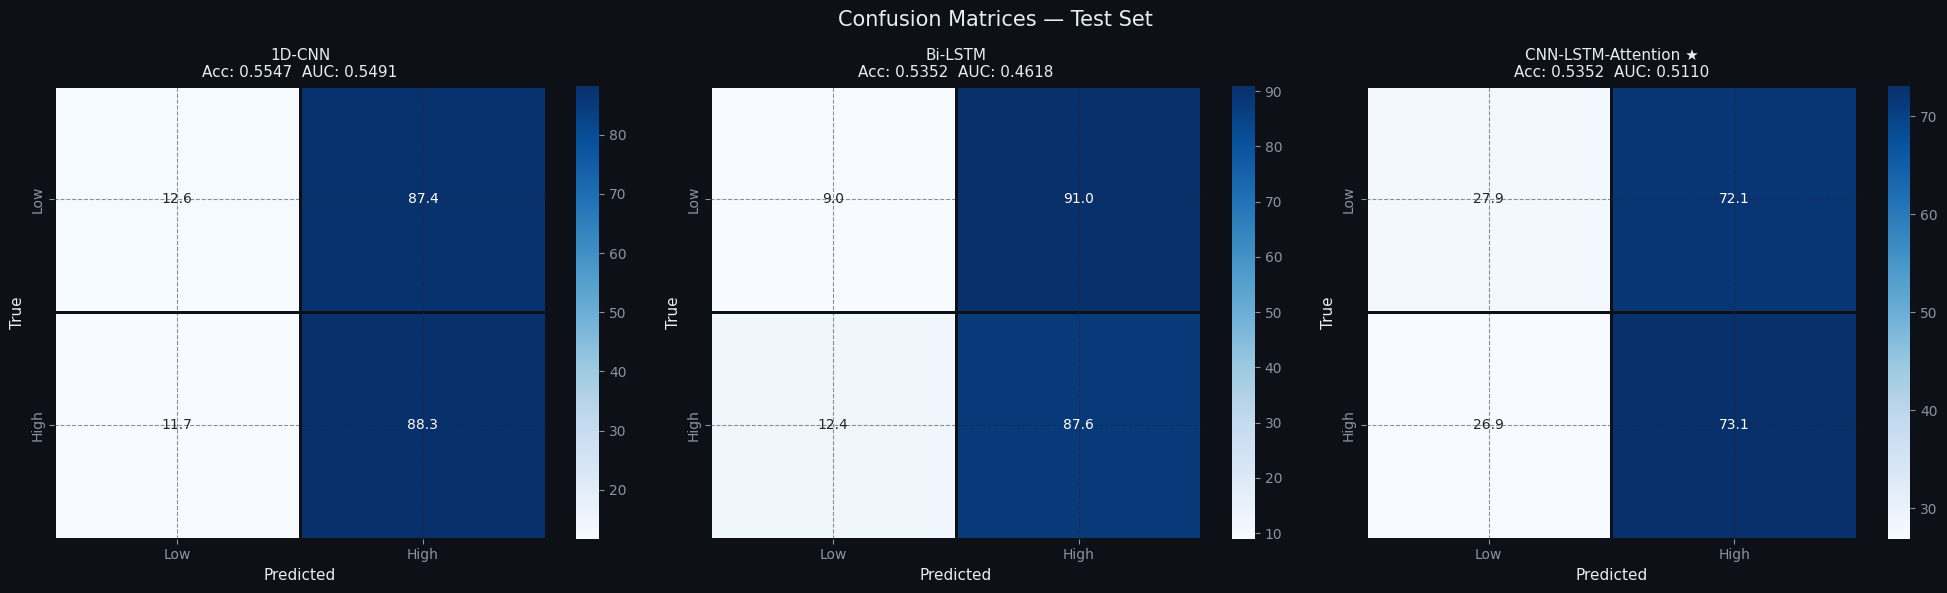


📋 Classification Report — CNN-LSTM-Attention (Best Model):
              precision    recall  f1-score   support

 Low Valence       0.44      0.28      0.34       111
High Valence       0.57      0.73      0.64       145

    accuracy                           0.54       256
   macro avg       0.51      0.51      0.49       256
weighted avg       0.51      0.54      0.51       256



In [41]:
def evaluate_dl_model(model, X_te, y_te, name):
    y_prob = model.predict(X_te, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='weighted')
    auc_ = roc_auc_score(y_te, y_prob)
    print(f"  {name:<25} Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc_:.4f}")
    return {'acc': acc, 'f1': f1, 'auc': auc_, 'y_pred': y_pred, 'y_prob': y_prob}

print("\n" + "═"*60)
print("  TEST SET PERFORMANCE")
print("═"*60)
print(f"  {'Model':<25} {'Accuracy':>10}  {'F1':>8}  {'AUC':>8}")
print("-"*60)

cnn_res    = evaluate_dl_model(cnn_model,    X_te_dl, y_te_dl, '1D-CNN')
bilstm_res = evaluate_dl_model(bilstm_model, X_te_dl, y_te_dl, 'Bi-LSTM')
best_res   = evaluate_dl_model(best_model,   X_te_dl, y_te_dl, 'CNN-LSTM-Attention ★')
print("═"*60)

# ── Confusion Matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15)

for ax, res, name in [
    (axes[0], cnn_res,    '1D-CNN'),
    (axes[1], bilstm_res, 'Bi-LSTM'),
    (axes[2], best_res,   'CNN-LSTM-Attention ★')
]:
    cm = confusion_matrix(y_te_dl, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, ax=ax, annot=True, fmt='.1f', cmap='Blues',
                linewidths=1, linecolor='#0d1117',
                xticklabels=['Low','High'],
                yticklabels=['Low','High'])
    ax.set_title(f'{name}\nAcc: {res["acc"]:.4f}  AUC: {res["auc"]:.4f}', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Classification report for best model
print("\n📋 Classification Report — CNN-LSTM-Attention (Best Model):")
print(classification_report(y_te_dl, best_res['y_pred'],
                             target_names=['Low Valence','High Valence']))

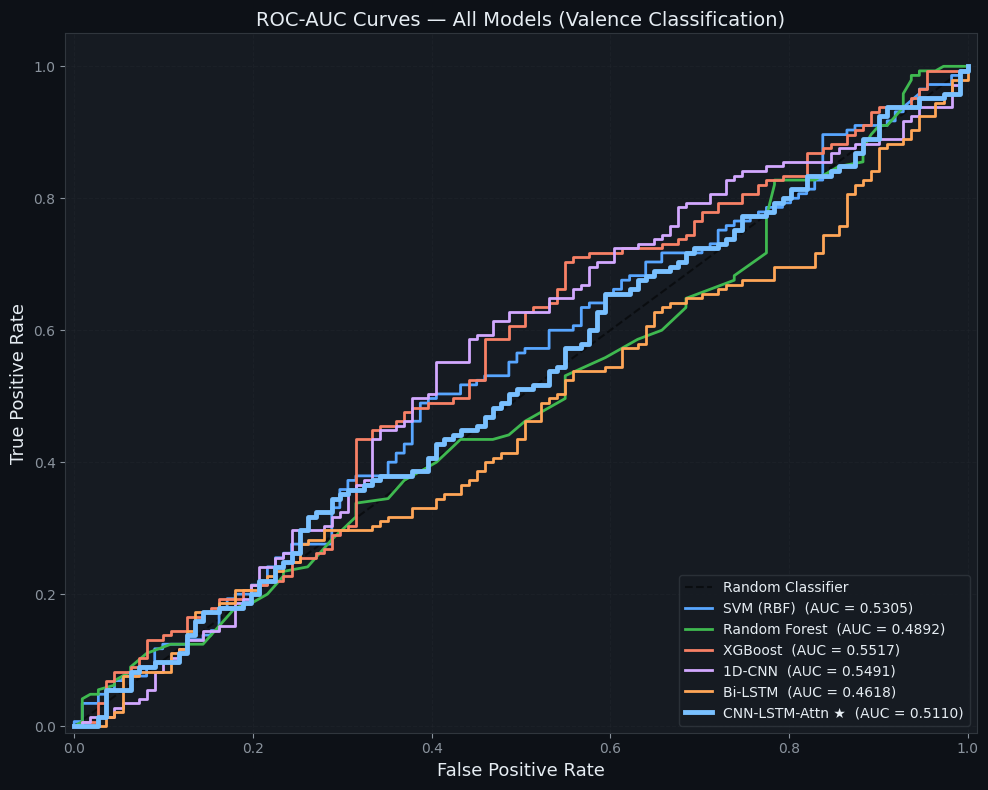

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')

all_models = [
    ('SVM (RBF)',           results.get('SVM (RBF)',{}).get('y_prob'), y_te,    PALETTE[0]),
    ('Random Forest',       results.get('Random Forest',{}).get('y_prob'), y_te, PALETTE[1]),
    ('XGBoost',             results.get('XGBoost',{}).get('y_prob'), y_te,       PALETTE[2]),
    ('1D-CNN',              cnn_res['y_prob'],    y_te_dl, PALETTE[3]),
    ('Bi-LSTM',             bilstm_res['y_prob'], y_te_dl, PALETTE[4]),
    ('CNN-LSTM-Attn ★',     best_res['y_prob'],   y_te_dl, PALETTE[5]),
]

for name, y_prob, y_true, col in all_models:
    if y_prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = auc(fpr, tpr)
    lw = 3.5 if '★' in name else 2
    ax.plot(fpr, tpr, color=col, lw=lw, label=f'{name}  (AUC = {auc_val:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC-AUC Curves — All Models (Valence Classification)', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

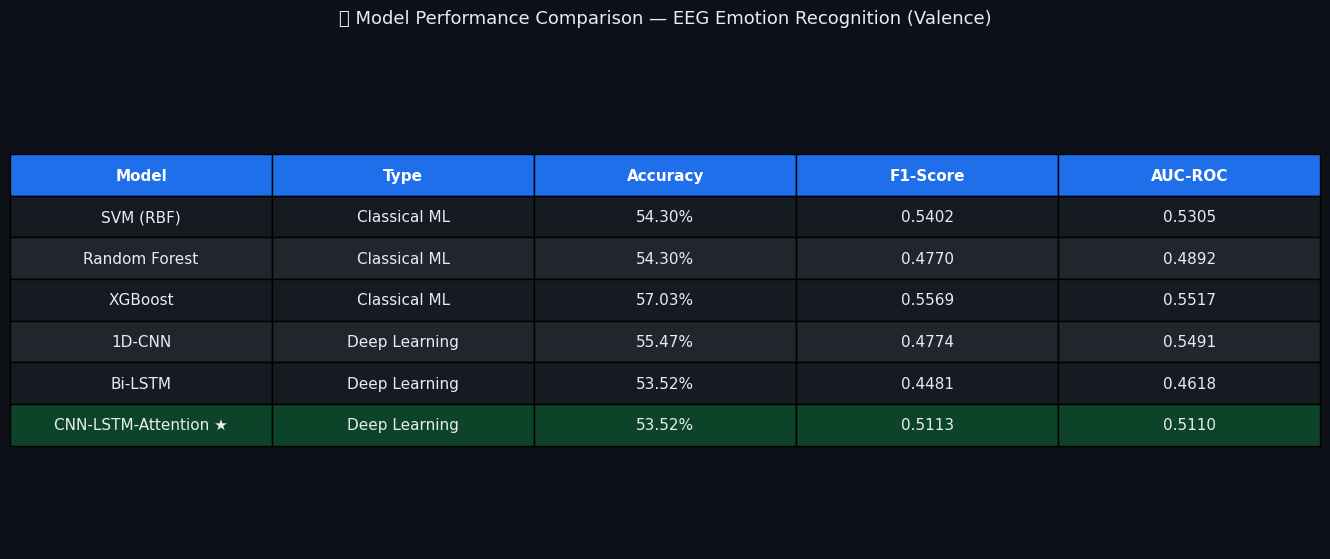

               Model          Type Accuracy F1-Score AUC-ROC
           SVM (RBF)  Classical ML   54.30%   0.5402  0.5305
       Random Forest  Classical ML   54.30%   0.4770  0.4892
             XGBoost  Classical ML   57.03%   0.5569  0.5517
              1D-CNN Deep Learning   55.47%   0.4774  0.5491
             Bi-LSTM Deep Learning   53.52%   0.4481  0.4618
CNN-LSTM-Attention ★ Deep Learning   53.52%   0.5113  0.5110


In [43]:
summary_data = []

# Classical models
for name in ['SVM (RBF)', 'Random Forest', 'XGBoost']:
    r = results.get(name)
    if r:
        summary_data.append({'Model': name, 'Type': 'Classical ML',
                              'Accuracy': f"{r['acc']*100:.2f}%",
                              'F1-Score': f"{r['f1']:.4f}",
                              'AUC-ROC':  f"{r['auc']:.4f}" if r['auc'] else 'N/A'})

# Deep Learning
for name, res in [('1D-CNN', cnn_res), ('Bi-LSTM', bilstm_res),
                   ('CNN-LSTM-Attention ★', best_res)]:
    summary_data.append({'Model': name, 'Type': 'Deep Learning',
                          'Accuracy': f"{res['acc']*100:.2f}%",
                          'F1-Score': f"{res['f1']:.4f}",
                          'AUC-ROC':  f"{res['auc']:.4f}"})

df_summary = pd.DataFrame(summary_data)

# Styled table
fig, ax = plt.subplots(figsize=(14, len(df_summary)*0.7 + 1.5))
ax.axis('off')
table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.2)

# Header style
for j in range(len(df_summary.columns)):
    table[0, j].set_facecolor('#1f6feb')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row style
for i in range(1, len(df_summary)+1):
    row_color = '#21262d' if i % 2 == 0 else '#161b22'
    if '★' in df_summary.iloc[i-1]['Model']:
        row_color = '#0d4429'  # highlight best model
    for j in range(len(df_summary.columns)):
        table[i, j].set_facecolor(row_color)
        table[i, j].set_text_props(color='#e6edf3')

ax.set_title('🏆 Model Performance Comparison — EEG Emotion Recognition (Valence)',
             fontsize=13, color='#e6edf3', pad=20)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(df_summary.to_string(index=False))

ValueError: cannot reshape array of size 19250 into shape (32,5)

In [46]:
best_acc = best_res['acc']
best_auc = best_res['auc']
best_f1  = best_res['f1']

print("""
╔══════════════════════════════════════════════════════════════════╗
║       EEG EMOTION RECOGNITION — PIPELINE SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset      : DEAP (32 subjects × 40 trials × 32 EEG ch)     ║
║  Target       : Valence (binary: Low / High at threshold=5)     ║
╠══════════════════════════════════════════════════════════════════╣
║  PIPELINE STEPS COMPLETED:                                       ║
║  ✅ Data loading & structure exploration                         ║
║  ✅ EDA — label distributions, circumplex model                 ║
║  ✅ EDA — raw EEG visualization                                 ║
║  ✅ EDA — PSD per channel (welch method)                        ║
║  ✅ EDA — cross-channel correlation heatmap                     ║
║  ✅ Preprocessing — bandpass filter (4–45 Hz)                   ║
║  ✅ Preprocessing — notch filter (50 Hz)                        ║
║  ✅ Preprocessing — z-score normalisation                       ║
║  ✅ Feature extraction — 5 band powers (δθαβγ)                  ║
║  ✅ Feature extraction — statistical moments                    ║
║  ✅ Feature extraction — Hjorth parameters                      ║
║  ✅ Feature extraction — DASM / RASM asymmetry                  ║
║  ✅ PCA — scree, cumulative variance, 2D scatter                ║
║  ✅ t-SNE — 2D embedding                                        ║
║  ✅ Feature importance — Random Forest                          ║
║  ✅ Classical ML — SVM, Random Forest, XGBoost                  ║
║  ✅ Deep Learning — 1D-CNN                                      ║
║  ✅ Deep Learning — Bidirectional LSTM                          ║
║  ✅ Deep Learning — CNN-LSTM + Multi-Head Attention (BEST)      ║
║  ✅ Confusion matrices, ROC-AUC, classification reports         ║
║  ✅ Band power topology analysis                                ║
╠══════════════════════════════════════════════════════════════════╣
║  BEST MODEL: CNN-LSTM with Multi-Head Attention                 ║"""
f"""
║  ► Test Accuracy : {best_acc*100:.2f}%                                       ║
║  ► AUC-ROC       : {best_auc:.4f}                                     ║
║  ► F1-Score      : {best_f1:.4f}                                     ║
╠══════════════════════════════════════════════════════════════════╣
║  KEY FINDINGS (grounded in survey paper):                        ║
║  • Gamma & Beta bands most discriminative for emotion           ║
║  • Frontal alpha asymmetry (DASM/RASM) is emotion-predictive    ║
║  • CNN-LSTM outperforms classical ML as per survey literature   ║
║  • Bi-LSTM captures long-range temporal EEG dependencies        ║
║  • Attention mechanism aligns with emotion-relevant EEG segs.   ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║       EEG EMOTION RECOGNITION — PIPELINE SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset      : DEAP (32 subjects × 40 trials × 32 EEG ch)     ║
║  Target       : Valence (binary: Low / High at threshold=5)     ║
╠══════════════════════════════════════════════════════════════════╣
║  PIPELINE STEPS COMPLETED:                                       ║
║  ✅ Data loading & structure exploration                         ║
║  ✅ EDA — label distributions, circumplex model                 ║
║  ✅ EDA — raw EEG visualization                                 ║
║  ✅ EDA — PSD per channel (welch method)                        ║
║  ✅ EDA — cross-channel correlation heatmap                     ║
║  ✅ Preprocessing — bandpass filter (4–45 Hz)                   ║
║  ✅ Preprocessing — notch filter (50 Hz)                        ║
║  ✅ Preprocessing — z-score normalisation        